In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
fig_dir = project_dir / "results/figures/441_x_cs6_extract"
table_dir = project_dir / "results/tables/441_x_c441_x_cs6_extracts6_check"
out_dir = project_dir / "results/processed"

fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)

In [ ]:
ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6-fig1.h5ad"
# ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6-fig2.h5ad"
# ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6-fig3.h5ad"
# ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6-fig4&fig5.h5ad"
# query_path = out_dir / "hemo_d1_10_revised_annotation.h5ad"

adata = sc.read_h5ad(ref_path)
# adata_hemo = sc.read_h5ad(query_path)

adata.var_names_make_unique()
# adata_hemo.var_names_make_unique()

adata

In [ ]:
adata.obs["celltype_final"].value_counts()

In [ ]:
selected_celltypes = [
    "PL.EXMC",
    "YS.Endo",
    "AM.EXMC",
    "YS.EXMC",
    "Hypo.2",
    "Hypo.1",
    "AVE_like_Hypo",
]

adata_sub = adata[adata.obs["celltype_final"].isin(selected_celltypes)].copy()

adata_sub

In [ ]:
import scanpy as sc

# ------------------------------------------------------------
# 1. Save raw counts to layers
# ------------------------------------------------------------
adata_sub.layers["counts"] = adata_sub.X.copy()
adata_sub.raw = adata_sub.copy()

# ------------------------------------------------------------
# 2. Basic preprocessing
# ------------------------------------------------------------
sc.pp.normalize_total(
    adata_sub,
    target_sum=1e4,
)

sc.pp.log1p(adata_sub)

# ------------------------------------------------------------
# 3. Highly variable genes
# ------------------------------------------------------------
sc.pp.highly_variable_genes(
    adata_sub,
    n_top_genes=3000,
    flavor="seurat_v3",
    layer="counts",
)

adata_sub_hvg = adata_sub[:, adata_sub.var["highly_variable"]].copy()

# ------------------------------------------------------------
# 4. Scale + PCA
# ------------------------------------------------------------
sc.pp.scale(
    adata_sub_hvg,
    max_value=10,
)

sc.tl.pca(
    adata_sub_hvg,
    svd_solver="arpack",
    n_comps=50,
)

# ------------------------------------------------------------
# 5. Neighbors + Leiden + UMAP
# ------------------------------------------------------------
sc.pp.neighbors(
    adata_sub_hvg,
    n_neighbors=15,
    n_pcs=30,
)

sc.tl.leiden(
    adata_sub_hvg,
    resolution=0.6,
    key_added="leiden_0.6",
)

sc.tl.umap(adata_sub_hvg)

# ------------------------------------------------------------
# 6. Copy embeddings / clustering back to adata_sub
# ------------------------------------------------------------
adata_sub.obsm["X_pca"] = adata_sub_hvg.obsm["X_pca"].copy()
adata_sub.obsm["X_umap"] = adata_sub_hvg.obsm["X_umap"].copy()
adata_sub.obs["leiden_0.6"] = adata_sub_hvg.obs["leiden_0.6"].copy()

# ------------------------------------------------------------
# 7. Quick plots
# ------------------------------------------------------------
sc.pl.umap(
    adata_sub,
    color=["celltype_final", "leiden_0.6"],
    frameon=False,
    wspace=0.4,
)

In [ ]:
sc.pl.umap(
    adata_sub,
    color=["celltype_final"],
    frameon=False,
    wspace=0.4,
)

In [ ]:
adata_sub.write_h5ad("/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6_sub.h5ad")

## method 1 load data (good)

In [3]:
query_path = out_dir / "hemo_d1_10_revised_annotation.h5ad"
ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6_sub.h5ad"
# adata_ref = adata_sub
adata_hemo = sc.read_h5ad(query_path)
adata_ref = sc.read_h5ad(ref_path)

adata_ref.var_names_make_unique()
adata_hemo.var_names_make_unique()

In [4]:
ref_label_key = "celltype_final"

query_label_key = "CellType_short"

In [5]:
exm_groups = [
    "Nasc Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
]

adata_q = adata_hemo[
    adata_hemo.obs[query_label_key].astype(str).isin(exm_groups)
].copy()

adata_q.obs["query_group"] = adata_q.obs[query_label_key].astype(str).astype("category")

print(adata_q.obs["query_group"].value_counts())
adata_q

query_group
Adv Mes      14631
YS Mes        1469
Nasc Mes      1404
Trans ExM     1258
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 18762 × 18732
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'batch', 'leiden', 'day', 'predicted_labels', 'majority_voting', 'conf_score', 'Tyser_label', 'Tyser_score', 'Xiang_label', 'Xiang_score', 'Tyser_label_v2', 'Tyser_score_v2', 'label', 'label_v2', 'over_clustering', 'hembryo_label', 'hembryo_score', 'leiden_annotation_Tyser_label', 'leiden_annotation_Tyser_label_v2', 'leiden_annotation_hembryo_label', 'leiden_annotation_v1', 'CellType_man', 'CellType_revised_id', 'CellType_revised_full', 'CellType_revised_short', 'CellType_short', 'query_group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_man_colors', 'CellType

In [6]:
shared_genes = adata_ref.var_names.intersection(adata_q.var_names)
print("Shared genes:", len(shared_genes))

adata_ref_sub = adata_ref[:, shared_genes].copy()
adata_q_sub = adata_q[:, shared_genes].copy()

Shared genes: 17444


In [7]:
print("Reference obsm keys:", adata_ref_sub.obsm.keys())
print("Reference uns keys:", adata_ref_sub.uns.keys())

Reference obsm keys: KeysView(AxisArrays with keys: X_pca, X_umap)
Reference uns keys: dict_keys(['celltype_final_colors', 'hvg', 'leiden_0.6_colors', 'log1p'])


In [8]:
ref_umap_key = "X_umap"

assert ref_umap_key in adata_ref_sub.obsm.keys(), f"{ref_umap_key} not found in adata_ref.obsm"

adata_ref_model = adata_ref_sub.copy()
adata_ref_model.obsm["X_umap"] = adata_ref_model.obsm[ref_umap_key].copy()

print(adata_ref_model.obsm["X_umap"].shape)

(83306, 2)


In [9]:
ref_latent_key = "X_umap"  

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# Make sure query uses exactly same genes as reference model
model_genes = adata_ref_model.var_names
adata_q_model = adata_q_sub[:, model_genes].copy()
adata_q_model.obs["query_group"] = adata_q_sub.obs["query_group"].copy()

# Normalize query if needed
if "counts" not in adata_q_model.layers:
    adata_q_model.layers["counts"] = adata_q_model.X.copy()

xq = adata_q_model.X
max_val_q = xq.max() if sparse.issparse(xq) else np.max(xq)

if max_val_q > 50:
    sc.pp.normalize_total(adata_q_model, target_sum=1e4)
    sc.pp.log1p(adata_q_model)

In [11]:
# Use reference model genes
X_ref = adata_ref_model.X
X_q = adata_q_model.X

if sparse.issparse(X_ref):
    X_ref = X_ref.toarray()
if sparse.issparse(X_q):
    X_q = X_q.toarray()

# Fit scaler + PCA on reference only
scaler = StandardScaler(with_mean=True, with_std=True)
X_ref_scaled = scaler.fit_transform(X_ref)
X_q_scaled = scaler.transform(X_q)

n_pcs = min(50, X_ref_scaled.shape[1] - 1)

pca = PCA(n_components=n_pcs, random_state=0)
X_ref_latent = pca.fit_transform(X_ref_scaled)
X_q_latent = pca.transform(X_q_scaled)

adata_ref_model.obsm["X_projection_pca"] = X_ref_latent
adata_q_model.obsm["X_projection_pca"] = X_q_latent

In [12]:
k = 30

nn = NearestNeighbors(
    n_neighbors=k,
    metric="cosine",
)
nn.fit(adata_ref_model.obsm["X_projection_pca"])

dist, idx = nn.kneighbors(adata_q_model.obsm["X_projection_pca"])

# Convert distances to weights
eps = 1e-8
weights = 1 / (dist + eps)
weights = weights / weights.sum(axis=1, keepdims=True)

ref_umap = adata_ref_model.obsm["X_umap"]

query_umap = np.sum(
    ref_umap[idx] * weights[:, :, None],
    axis=1,
)

adata_q_model.obsm["X_umap"] = query_umap

In [13]:
ref_labels = adata_ref_model.obs[ref_label_key].astype(str).values

pred_labels = []
pred_scores = []

for neigh_idx, w in zip(idx, weights):
    labels = ref_labels[neigh_idx]
    score_by_label = {}
    for lab, ww in zip(labels, w):
        score_by_label[lab] = score_by_label.get(lab, 0) + ww

    best_label = max(score_by_label, key=score_by_label.get)
    best_score = score_by_label[best_label]

    pred_labels.append(best_label)
    pred_scores.append(best_score)

adata_q_model.obs[f"pred_{ref_label_key}"] = pd.Categorical(pred_labels)
adata_q_model.obs[f"pred_{ref_label_key}_score"] = pred_scores

In [14]:
pd.crosstab(
    adata_q_model.obs["query_group"],
    adata_q_model.obs[f"pred_{ref_label_key}"],
    normalize="index",
).round(3)

pred_celltype_final,AM.EXMC,Hypo.2,PL.EXMC,YS.EXMC,YS.Endo
query_group,,,,,
Adv Mes,0.780,0.000,0.217,0.003,0.000
Nasc Mes,0.986,0.004,0.009,0.000,0.000
Trans ExM,0.584,0.009,0.344,0.061,0.002
YS Mes,0.598,0.000,0.008,0.393,0.000


In [15]:
adata_ref_plot = adata_ref_model.copy()
adata_ref_plot.obs["dataset"] = "CS6 embryo"
adata_ref_plot.obs["plot_group"] = "Reference"
adata_ref_plot.obs["query_group"] = "Reference"

adata_q_plot = adata_q_model.copy()
adata_q_plot.obs["dataset"] = "HEMO query"
adata_q_plot.obs["plot_group"] = adata_q_plot.obs["query_group"].astype(str)

adata_combined = adata_ref_plot.concatenate(
    adata_q_plot,
    batch_key="projection_batch",
    batch_categories=["reference", "query"],
    index_unique=None,
)

adata_combined.obsm["X_umap"] = np.vstack([
    adata_ref_plot.obsm["X_umap"],
    adata_q_plot.obsm["X_umap"],
])

/tmp/ipykernel_3386584/78920337.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_ref_plot.concatenate(
/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [16]:
# =============================================================================
# Plot group for projection
# Query ExM cells = their query_group names
# All other cells = "Reference / other query"
# =============================================================================

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

exm_groups = [
    "Nasc Mes",
    "Adv Mes",
    "Trans ExM",
    "YS Mes",
]

projection_bg_label = "CS6 embryo"
projection_bg_color = "#D9D9D9"

query_color_map = {
    "Nasc Mes": "#BCBD22",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",
}

assert "query_group" in adata_combined.obs.columns, "adata_combined.obs has no query_group"

# Start with all cells as background
adata_combined.obs["plot_group"] = projection_bg_label

# Only query ExM cells get their real group labels
is_query_exm = adata_combined.obs["query_group"].astype(str).isin(exm_groups)
adata_combined.obs.loc[is_query_exm, "plot_group"] = (
    adata_combined.obs.loc[is_query_exm, "query_group"].astype(str)
)

# Explicit category order controls legend order
plot_group_order = exm_groups + [projection_bg_label]

adata_combined.obs["plot_group"] = pd.Categorical(
    adata_combined.obs["plot_group"],
    categories=plot_group_order,
    ordered=True,
)

# Colors must follow category order exactly
adata_combined.uns["plot_group_colors"] = [
    query_color_map[x] if x in query_color_map else projection_bg_color
    for x in adata_combined.obs["plot_group"].cat.categories
]

print(dict(zip(
    adata_combined.obs["plot_group"].cat.categories,
    adata_combined.uns["plot_group_colors"],
)))

{'Nasc Mes': '#BCBD22', 'Adv Mes': '#8C564B', 'Trans ExM': '#17BECF', 'YS Mes': '#FF9896', 'CS6 embryo': '#D9D9D9'}


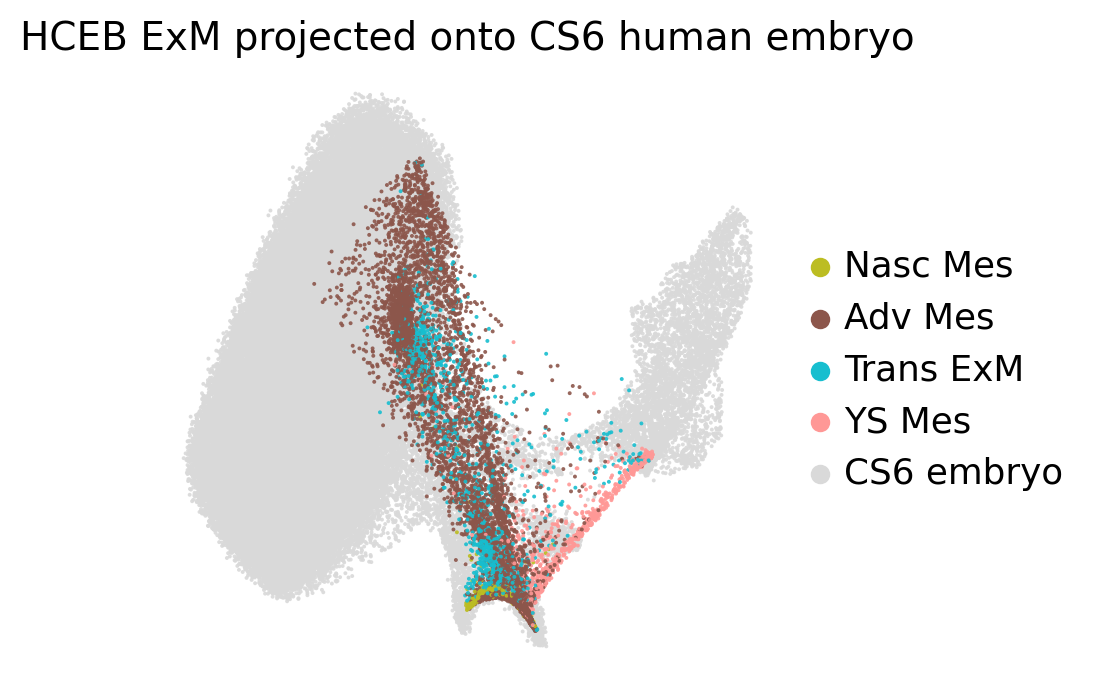

In [17]:
# fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.umap(
    adata_combined,
    color="plot_group",
    frameon=False,
    size=8,
    alpha=0.9,
    title="HCEB ExM projected onto CS6 human embryo",
)

# fig.savefig(
#     fig_dir / "projection_HCEB_ExM_to_cs6_sub.pdf",
#     bbox_inches="tight",
#     facecolor="white",
# )

# plt.show()

highlight_Nasc Mes
{'CS6 embryo': '#D9D9D9', 'Nasc Mes': '#BCBD22'}


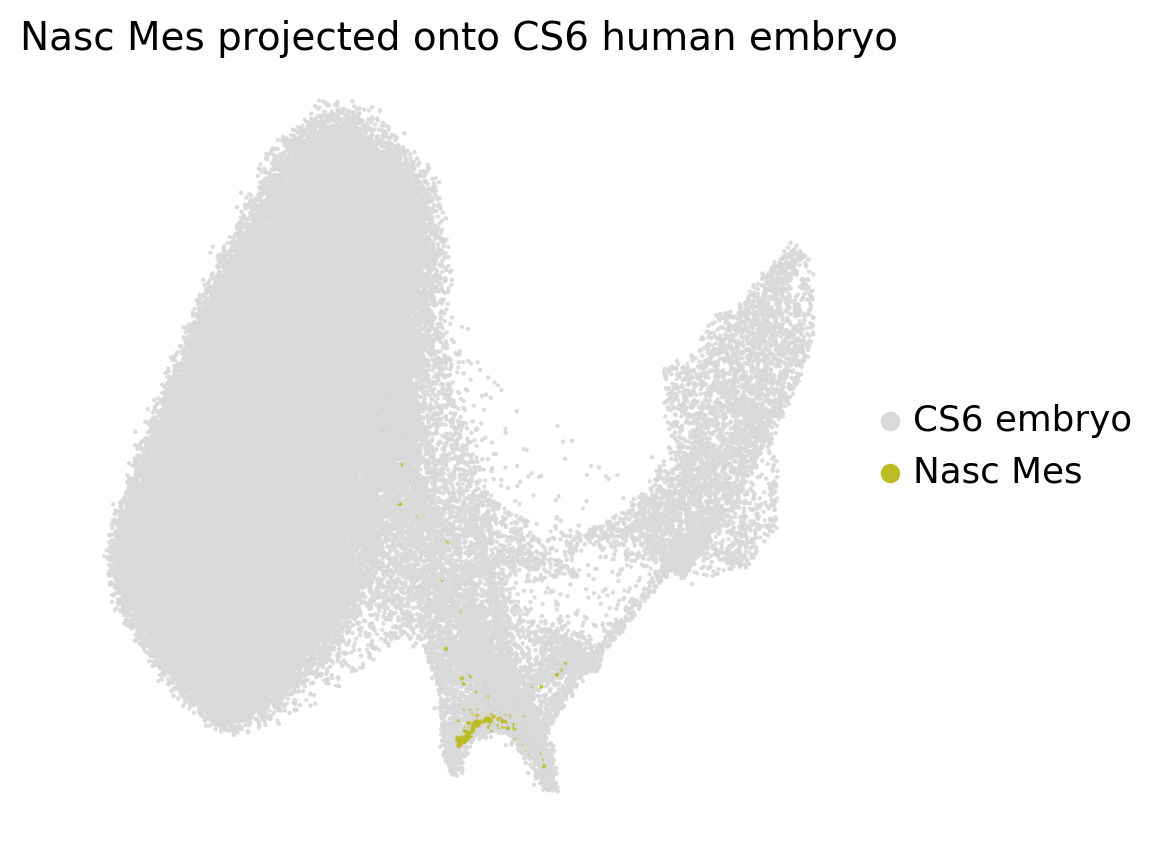

highlight_Trans ExM
{'CS6 embryo': '#D9D9D9', 'Trans ExM': '#17BECF'}


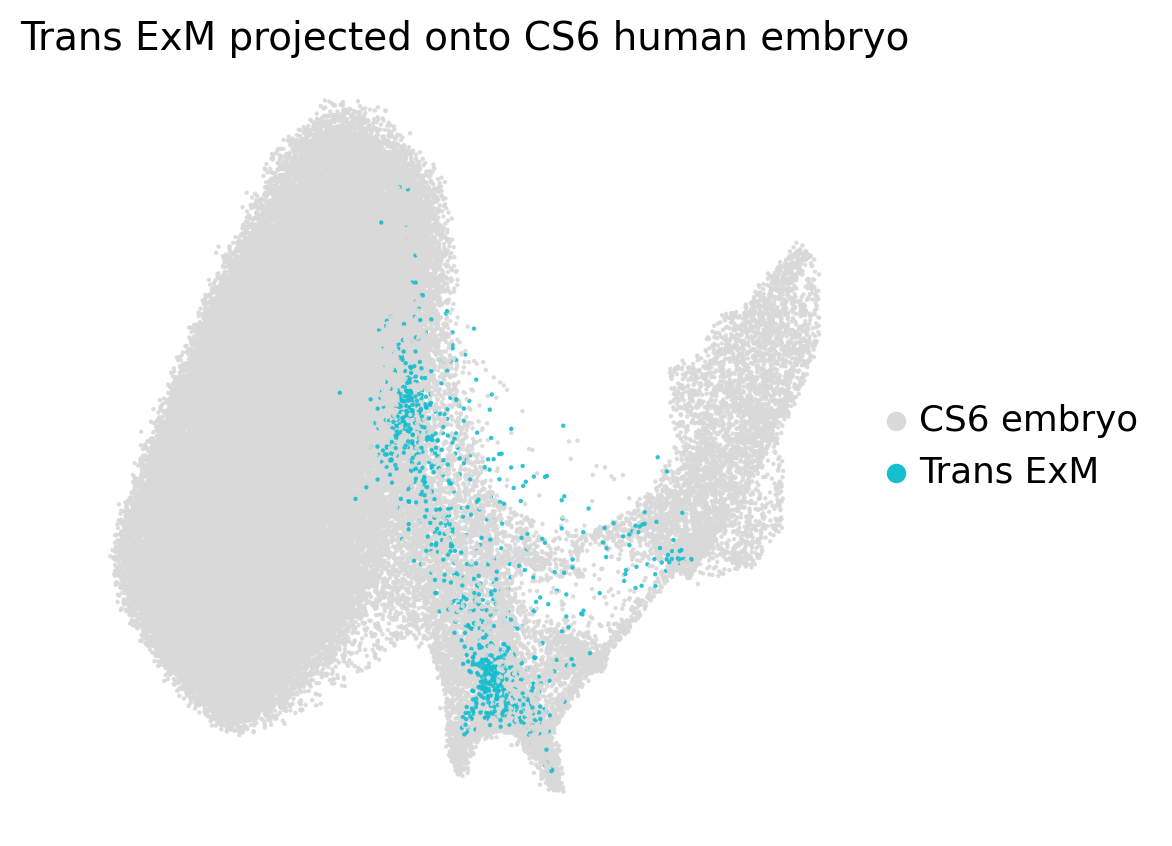

highlight_Adv Mes
{'CS6 embryo': '#D9D9D9', 'Adv Mes': '#8C564B'}


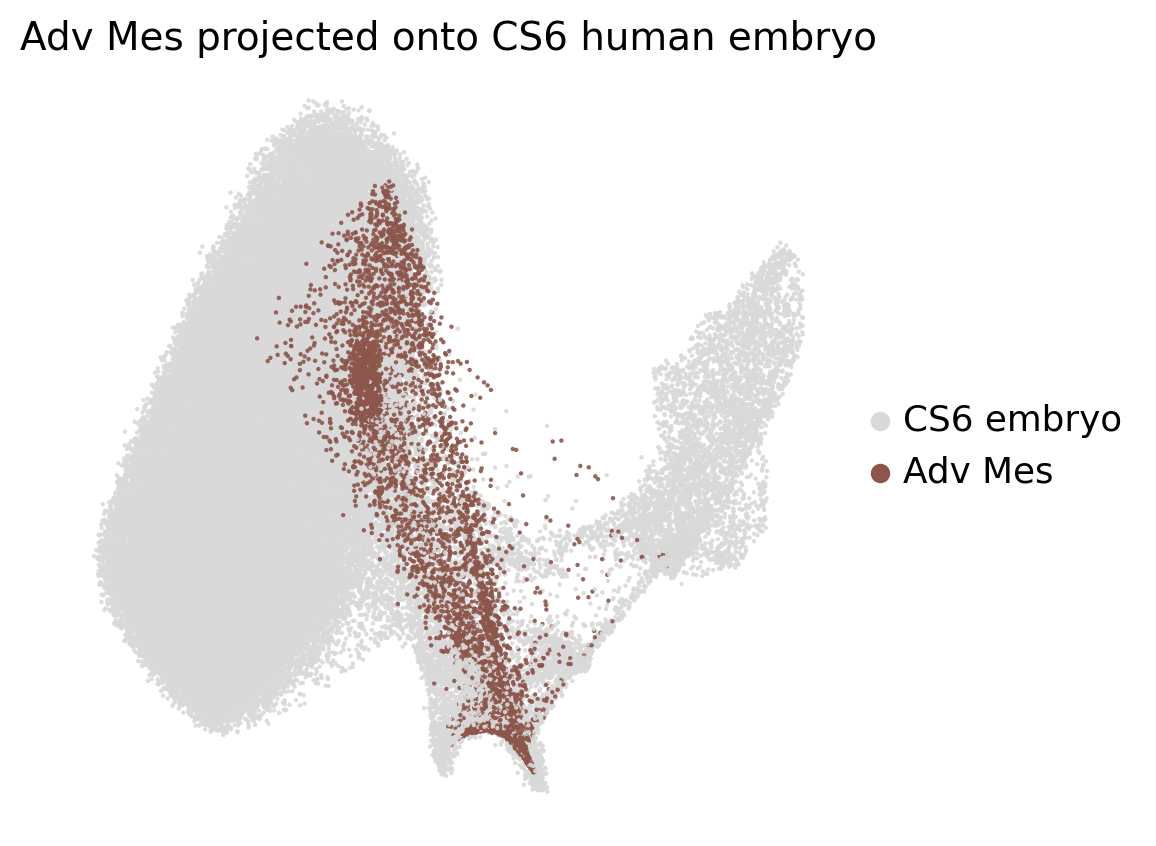

highlight_YS Mes
{'CS6 embryo': '#D9D9D9', 'YS Mes': '#FF9896'}


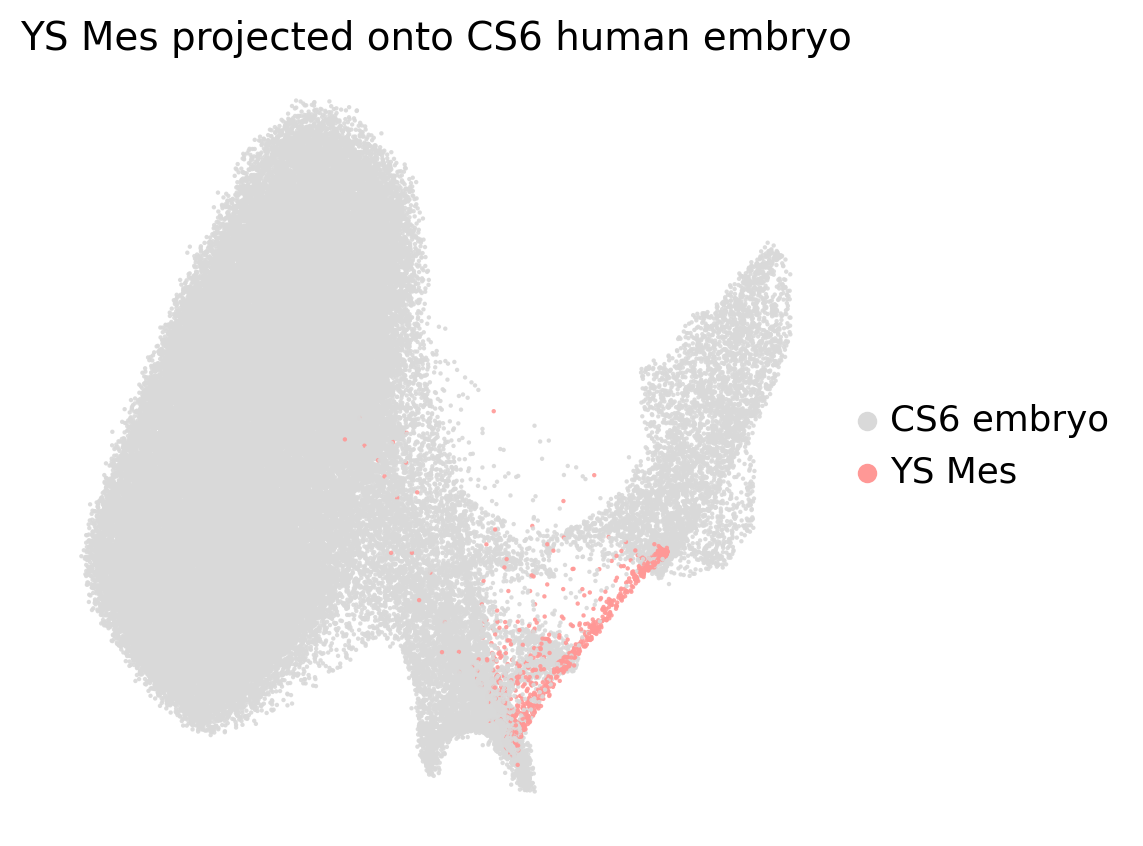

In [28]:
# =============================================================================
# Individual highlight plots with consistent colors
# =============================================================================

for group in exm_groups:
    highlight_key = f"highlight_{group}"

    adata_combined.obs[highlight_key] = "CS6 embryo"

    mask = adata_combined.obs["query_group"].astype(str).eq(group)
    adata_combined.obs.loc[mask, highlight_key] = group

    # fixed category order: background first, highlighted group second
    adata_combined.obs[highlight_key] = pd.Categorical(
        adata_combined.obs[highlight_key],
        categories=["CS6 embryo", group],
        ordered=True,
    )

    # IMPORTANT: colors follow category order exactly
    adata_combined.uns[f"{highlight_key}_colors"] = [
        projection_bg_color,
        query_color_map[group],
    ]

    print(highlight_key)
    print(dict(zip(
        adata_combined.obs[highlight_key].cat.categories,
        adata_combined.uns[f"{highlight_key}_colors"],
    )))

    fig, ax = plt.subplots(figsize=(5, 5))

    sc.pl.umap(
        adata_combined,
        color=highlight_key,
        frameon=False,
        size=10,
        alpha=0.9,
        title=f"{group} projected onto CS6 human embryo",
        ax=ax,
        show=False,
    )

    safe_group = group.replace(" ", "_").replace("/", "_")

    fig.savefig(
        fig_dir / f"projection_{safe_group}_to_X_umap.pdf",
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# Top10 similarity heatmap
# Based on kNN weights from projection:
#   idx: query cells x k reference neighbor indices
#   weights: query cells x k neighbor weights
#   ref_labels: reference labels for all reference cells
# =============================================================================

exm_groups = [
    "Nasc Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
]

ref_labels = adata_ref_model.obs[ref_label_key].astype(str).values

# query group
query_groups = adata_q_model.obs["query_group"].astype(str).values

celltype_scores = []

for q_i in range(idx.shape[0]):
    neigh_idx = idx[q_i]
    neigh_weights = weights[q_i]

    labels = ref_labels[neigh_idx]

    score_dict = {}
    for lab, w in zip(labels, neigh_weights):
        score_dict[lab] = score_dict.get(lab, 0) + w

    celltype_scores.append(score_dict)

score_df = pd.DataFrame(celltype_scores).fillna(0)
score_df.index = adata_q_model.obs_names
score_df["query_group"] = query_groups

# =============================================================================
# Average similarity per HEMO query group
# =============================================================================

sim_mat = (
    score_df
    .groupby("query_group")
    .mean(numeric_only=True)
)

# keep only four groups and preferred order
sim_mat = sim_mat.loc[[g for g in exm_groups if g in sim_mat.index]]

# =============================================================================
# Select top10 reference identities by maximum similarity across four groups
# =============================================================================

top10_ref_celltypes = (
    sim_mat
    .max(axis=0)
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

sim_top10 = sim_mat.loc[:, top10_ref_celltypes]

# save table
sim_top10.to_csv(
    table_dir / "hemo_exm_projection_top10_similarity_heatmap_matrix.csv"
)

sim_top10

,AM.EXMC,YS.EXMC,PL.EXMC,Hypo.2,YS.Endo,Hypo.1
query_group,,,,,,
Nasc Mes,0.984096,0.000023,0.009339,0.006280,0.000000,0.000263
Trans ExM,0.578118,0.077720,0.323689,0.015764,0.003524,0.001184
Adv Mes,0.775663,0.005877,0.218076,0.000300,0.000080,0.000004
YS Mes,0.563386,0.411758,0.024451,0.000000,0.000405,0.000000


In [25]:
def plot_sim_top10_barplot_by_query_group(
    sim_top10,
    query_group,
    color_dict,
    figsize=(4.2, 3.2),
    ylim=(0, 0.65),
    title=None,
    save_path=None,
    dpi=600,
):
    """
    Plot ordinary barplot for one query group.
    Bar colors are matched by reference celltype names using color_dict.
    """

    if query_group not in sim_top10.index:
        raise ValueError(f"{query_group} not found in sim_top10.index")

    s = sim_top10.loc[query_group].sort_values(ascending=False)

    x = np.arange(len(s))
    colors = [color_dict.get(ct, "#BDBDBD") for ct in s.index]

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        x,
        s.values,
        color=colors,
        width=0.75,
        edgecolor="none",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        s.index.tolist(),
        rotation=45,
        ha="right",
    )

    ax.set_ylabel("Mean kNN similarity")

    if ylim is not None:
        ax.set_ylim(*ylim)

    if title is None:
        title = query_group

    ax.set_title(title, pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)

        fig.savefig(
            save_path.with_suffix(".pdf"),
            bbox_inches="tight",
            facecolor="white",
        )

        print("Saved:")
        print(save_path.with_suffix(".pdf"))

    plt.show()

    return fig, ax, s

In [26]:
ref_celltype_merged_v3_color_dict = {
    "Advanced Mesoderm": "#1f77b4",
    "Allantois": "#aec7e8",
    "Ambiguous": "#ff7f0e",
    "Amnion": "#ffbb78",
    "Blood Progenitors": "#2ca02c",
    "Connecting Stalk": "#98df8a",
    "Definitive Endoderm": "#d62728",
    "Early Hypoblast": "#ff9896",
    "Endoderm": "#9467bd",
    "Epiblast": "#c5b0d5",
    "Epiblast/Ectoderm": "#8c564b",
    "Erythroid": "#c49c94",
    "ExE Mesoderm": "#e377c2",
    "Gut Endoderm": "#f7b6d2",
    "Hemato-endothelial": "#7f7f7f",
    "Late Hypoblast": "#c7c7c7",
    "Megakaryocyte": "#bcbd22",
    "Mesoderm": "#dbdb8d",
    "Mixed Mesoderm": "#17becf",
    "Myeloid": "#9edae5",
    "Neural": "#393b79",
    "Neuromesodermal Progenitor": "#5254a3",
    "Preimplantation": "#6b6ecf",
    "Primitive Streak": "#9c9ede",
    "Primordial Germ Cells": "#637939",
    "Surface Ectoderm": "#8ca252",
    "Trophectoderm": "#b5cf6b",
    "Trophoblast": "#cedb9c",
    "Unknown": "#8c6d31",
    "Visceral Endoderm": "#bd9e39",
    "YS Endoderm": "#e7ba52",
    "YS Mesoderm": "#e7cb94",
}

Saved:
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/441_x_cs6_extract/projection_top10_similarity_barplot_Nasc_Mes.pdf


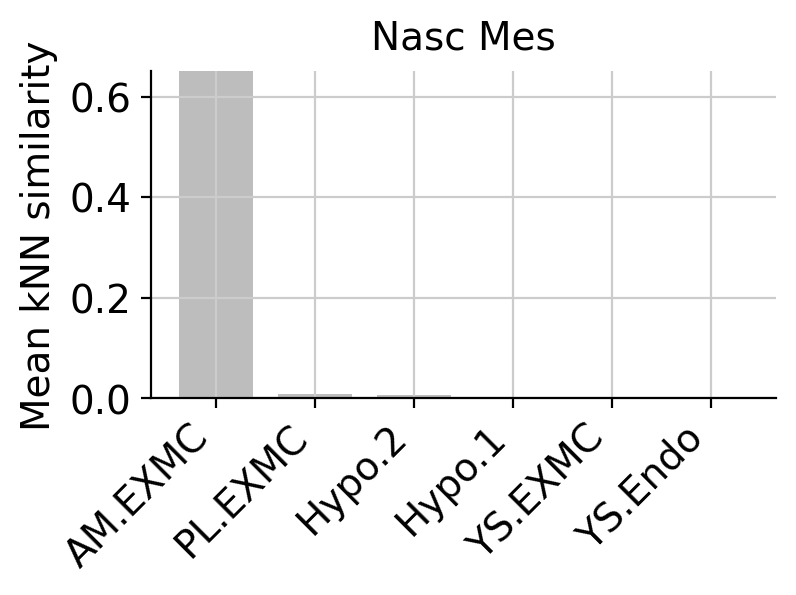

Saved:
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/441_x_cs6_extract/projection_top10_similarity_barplot_Trans_ExM.pdf


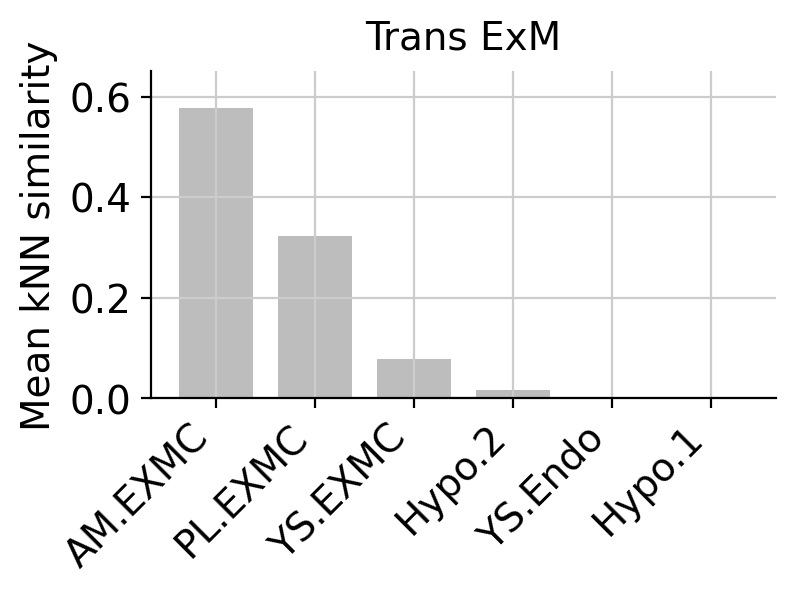

Saved:
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/441_x_cs6_extract/projection_top10_similarity_barplot_Adv_Mes.pdf


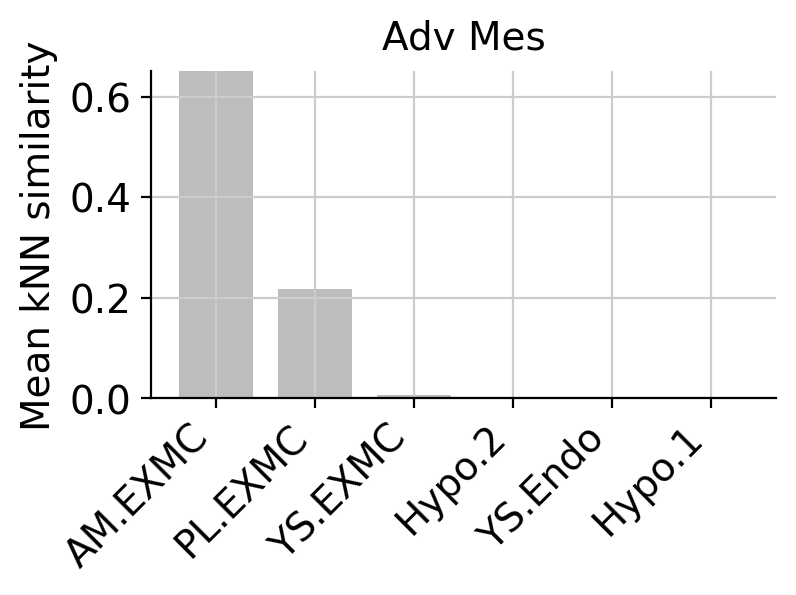

Saved:
/mnt/yiming/nfs_share/projects/hypoblast/results/figures/441_x_cs6_extract/projection_top10_similarity_barplot_YS_Mes.pdf


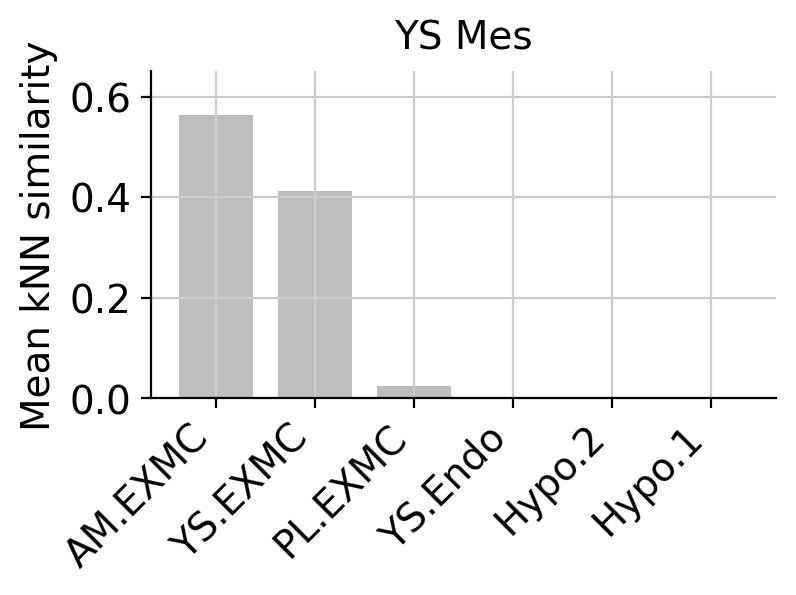

In [27]:
for group in ["Nasc Mes", "Trans ExM", "Adv Mes", "YS Mes"]:
    safe_group = group.replace(" ", "_").replace("/", "_")

    fig, ax, s = plot_sim_top10_barplot_by_query_group(
        sim_top10,
        query_group=group,
        color_dict=ref_celltype_merged_v3_color_dict,
        figsize=(4.2, 3.2),
        ylim=(0, 0.65),
        title=f"{group}",
        save_path=fig_dir / f"projection_top10_similarity_barplot_{safe_group}",
        dpi=600,
    )

## method 1 projection gene expression

In [5]:
query_path = out_dir / "hemo_d1_10_revised_annotation.h5ad"
ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6_sub.h5ad"
# adata_ref = adata_sub
adata_hemo = sc.read_h5ad(query_path)
adata_ref = sc.read_h5ad(ref_path)

adata_ref.var_names_make_unique()
adata_hemo.var_names_make_unique()

In [6]:
ref_label_key = "celltype_final"

query_label_key = "CellType_short"

In [7]:
exm_groups = [
    # "Nasc Mes",
    "Trans ExM",
    # "Adv Mes",
    # "YS Mes",
]

adata_q = adata_hemo[
    adata_hemo.obs[query_label_key].astype(str).isin(exm_groups)
].copy()

adata_q.obs["query_group"] = adata_q.obs[query_label_key].astype(str).astype("category")

print(adata_q.obs["query_group"].value_counts())
adata_q

query_group
Trans ExM    1258
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 1258 × 18732
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'batch', 'leiden', 'day', 'predicted_labels', 'majority_voting', 'conf_score', 'Tyser_label', 'Tyser_score', 'Xiang_label', 'Xiang_score', 'Tyser_label_v2', 'Tyser_score_v2', 'label', 'label_v2', 'over_clustering', 'hembryo_label', 'hembryo_score', 'leiden_annotation_Tyser_label', 'leiden_annotation_Tyser_label_v2', 'leiden_annotation_hembryo_label', 'leiden_annotation_v1', 'CellType_man', 'CellType_revised_id', 'CellType_revised_full', 'CellType_revised_short', 'CellType_short', 'query_group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_man_colors', 'CellType_

In [8]:
shared_genes = adata_ref.var_names.intersection(adata_q.var_names)
print("Shared genes:", len(shared_genes))

adata_ref_sub = adata_ref[:, shared_genes].copy()
adata_q_sub = adata_q[:, shared_genes].copy()

Shared genes: 17444


In [9]:
print("Reference obsm keys:", adata_ref_sub.obsm.keys())
print("Reference uns keys:", adata_ref_sub.uns.keys())

Reference obsm keys: KeysView(AxisArrays with keys: X_pca, X_umap)
Reference uns keys: dict_keys(['celltype_final_colors', 'hvg', 'leiden_0.6_colors', 'log1p'])


In [10]:
ref_umap_key = "X_umap"

assert ref_umap_key in adata_ref_sub.obsm.keys(), f"{ref_umap_key} not found in adata_ref.obsm"

adata_ref_model = adata_ref_sub.copy()
adata_ref_model.obsm["X_umap"] = adata_ref_model.obsm[ref_umap_key].copy()

print(adata_ref_model.obsm["X_umap"].shape)

(83306, 2)


In [11]:
ref_latent_key = "X_umap"  

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# Make sure query uses exactly same genes as reference model
model_genes = adata_ref_model.var_names
adata_q_model = adata_q_sub[:, model_genes].copy()
adata_q_model.obs["query_group"] = adata_q_sub.obs["query_group"].copy()

# Normalize query if needed
if "counts" not in adata_q_model.layers:
    adata_q_model.layers["counts"] = adata_q_model.X.copy()

xq = adata_q_model.X
max_val_q = xq.max() if sparse.issparse(xq) else np.max(xq)

if max_val_q > 50:
    sc.pp.normalize_total(adata_q_model, target_sum=1e4)
    sc.pp.log1p(adata_q_model)

In [13]:
# Use reference model genes
X_ref = adata_ref_model.X
X_q = adata_q_model.X

if sparse.issparse(X_ref):
    X_ref = X_ref.toarray()
if sparse.issparse(X_q):
    X_q = X_q.toarray()

# Fit scaler + PCA on reference only
scaler = StandardScaler(with_mean=True, with_std=True)
X_ref_scaled = scaler.fit_transform(X_ref)
X_q_scaled = scaler.transform(X_q)

n_pcs = min(50, X_ref_scaled.shape[1] - 1)

pca = PCA(n_components=n_pcs, random_state=0)
X_ref_latent = pca.fit_transform(X_ref_scaled)
X_q_latent = pca.transform(X_q_scaled)

adata_ref_model.obsm["X_projection_pca"] = X_ref_latent
adata_q_model.obsm["X_projection_pca"] = X_q_latent

In [14]:
k = 30

nn = NearestNeighbors(
    n_neighbors=k,
    metric="cosine",
)
nn.fit(adata_ref_model.obsm["X_projection_pca"])

dist, idx = nn.kneighbors(adata_q_model.obsm["X_projection_pca"])

# Convert distances to weights
eps = 1e-8
weights = 1 / (dist + eps)
weights = weights / weights.sum(axis=1, keepdims=True)

ref_umap = adata_ref_model.obsm["X_umap"]

query_umap = np.sum(
    ref_umap[idx] * weights[:, :, None],
    axis=1,
)

adata_q_model.obsm["X_umap"] = query_umap

In [15]:
ref_labels = adata_ref_model.obs[ref_label_key].astype(str).values

pred_labels = []
pred_scores = []

for neigh_idx, w in zip(idx, weights):
    labels = ref_labels[neigh_idx]
    score_by_label = {}
    for lab, ww in zip(labels, w):
        score_by_label[lab] = score_by_label.get(lab, 0) + ww

    best_label = max(score_by_label, key=score_by_label.get)
    best_score = score_by_label[best_label]

    pred_labels.append(best_label)
    pred_scores.append(best_score)

adata_q_model.obs[f"pred_{ref_label_key}"] = pd.Categorical(pred_labels)
adata_q_model.obs[f"pred_{ref_label_key}_score"] = pred_scores

In [16]:
pd.crosstab(
    adata_q_model.obs["query_group"],
    adata_q_model.obs[f"pred_{ref_label_key}"],
    normalize="index",
).round(3)

pred_celltype_final,AM.EXMC,Hypo.2,PL.EXMC,YS.EXMC,YS.Endo
query_group,,,,,
Trans ExM,0.584,0.009,0.344,0.061,0.002


In [17]:
adata_ref_plot = adata_ref_model.copy()
adata_ref_plot.obs["dataset"] = "CS6 embryo"
adata_ref_plot.obs["plot_group"] = "Reference"
adata_ref_plot.obs["query_group"] = "Reference"

adata_q_plot = adata_q_model.copy()
adata_q_plot.obs["dataset"] = "HEMO query"
adata_q_plot.obs["plot_group"] = adata_q_plot.obs["query_group"].astype(str)

adata_combined = adata_ref_plot.concatenate(
    adata_q_plot,
    batch_key="projection_batch",
    batch_categories=["reference", "query"],
    index_unique=None,
)

adata_combined.obsm["X_umap"] = np.vstack([
    adata_ref_plot.obsm["X_umap"],
    adata_q_plot.obsm["X_umap"],
])

/tmp/ipykernel_4081097/78920337.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_ref_plot.concatenate(
/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [18]:
# =============================================================================
# Plot group for projection
# Query ExM cells = their query_group names
# All other cells = "Reference / other query"
# =============================================================================

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

exm_groups = [
    # "Nasc Mes",
    # "Adv Mes",
    "Trans ExM",
    # "YS Mes",
]

projection_bg_label = "CS6 embryo"
projection_bg_color = "#D9D9D9"

query_color_map = {
    # "Nasc Mes": "#BCBD22",
    # "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    # "YS Mes": "#FF9896",
}

assert "query_group" in adata_combined.obs.columns, "adata_combined.obs has no query_group"

# Start with all cells as background
adata_combined.obs["plot_group"] = projection_bg_label

# Only query ExM cells get their real group labels
is_query_exm = adata_combined.obs["query_group"].astype(str).isin(exm_groups)
adata_combined.obs.loc[is_query_exm, "plot_group"] = (
    adata_combined.obs.loc[is_query_exm, "query_group"].astype(str)
)

# Explicit category order controls legend order
plot_group_order = exm_groups + [projection_bg_label]

adata_combined.obs["plot_group"] = pd.Categorical(
    adata_combined.obs["plot_group"],
    categories=plot_group_order,
    ordered=True,
)

# Colors must follow category order exactly
adata_combined.uns["plot_group_colors"] = [
    query_color_map[x] if x in query_color_map else projection_bg_color
    for x in adata_combined.obs["plot_group"].cat.categories
]

print(dict(zip(
    adata_combined.obs["plot_group"].cat.categories,
    adata_combined.uns["plot_group_colors"],
)))

{'Trans ExM': '#17BECF', 'CS6 embryo': '#D9D9D9'}


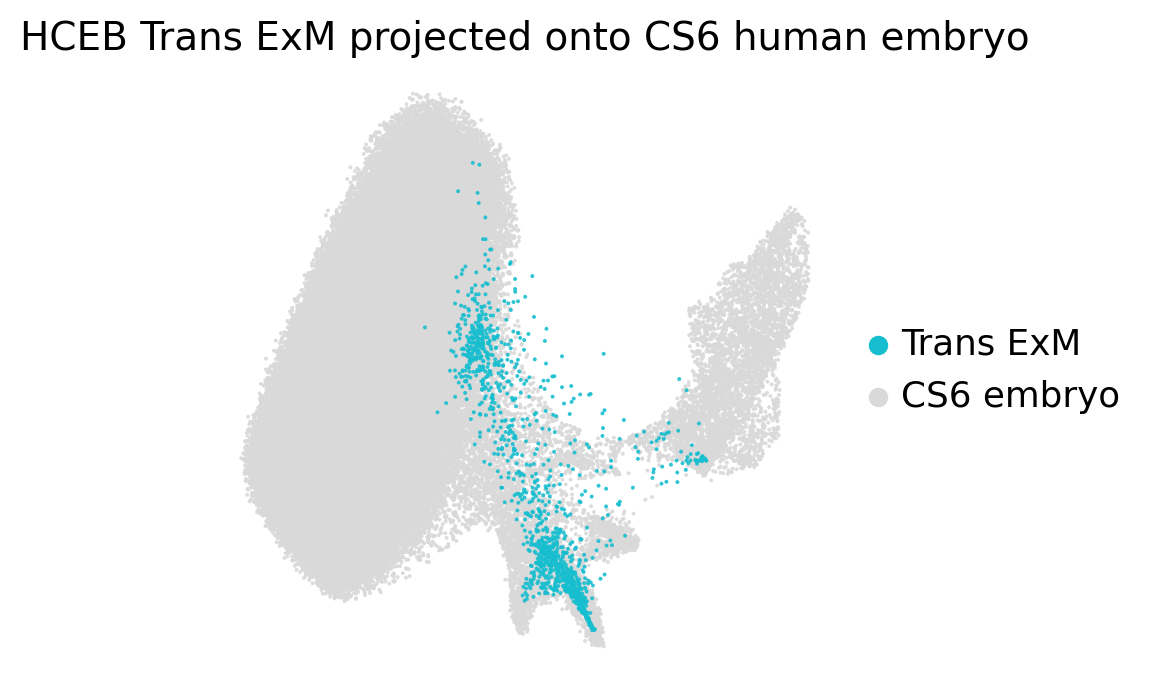

In [19]:
# fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.umap(
    adata_combined,
    color="plot_group",
    frameon=False,
    size=8,
    alpha=0.9,
    title="HCEB Trans ExM projected onto CS6 human embryo",
)

# fig.savefig(
#     fig_dir / "projection_HCEB_ExM_to_cs6_sub.pdf",
#     bbox_inches="tight",
#     facecolor="white",
# )

# plt.show()

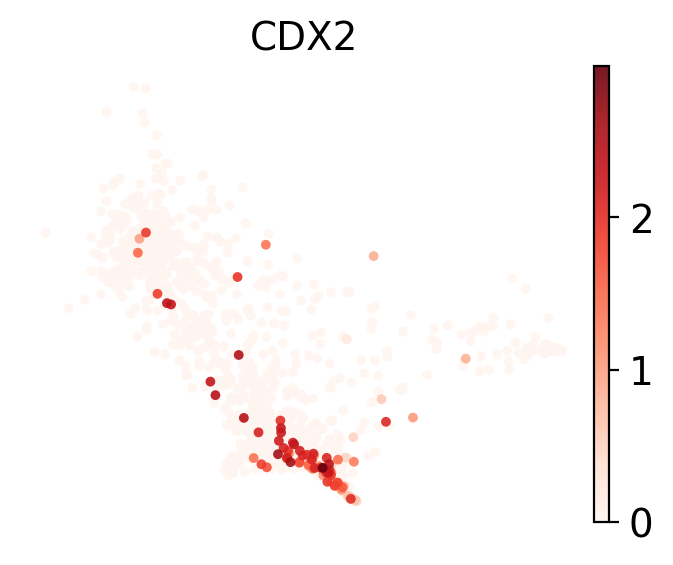

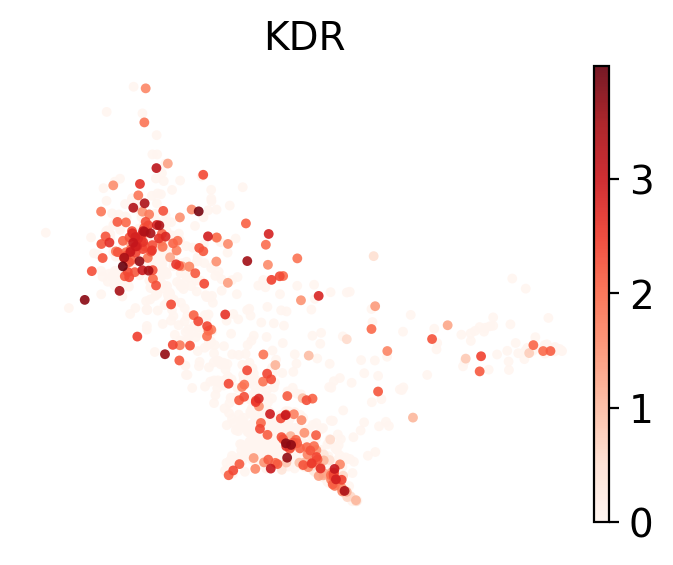

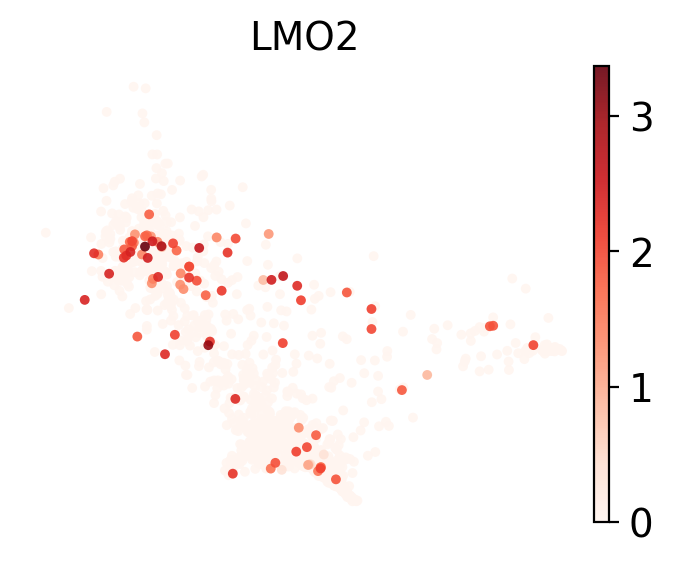

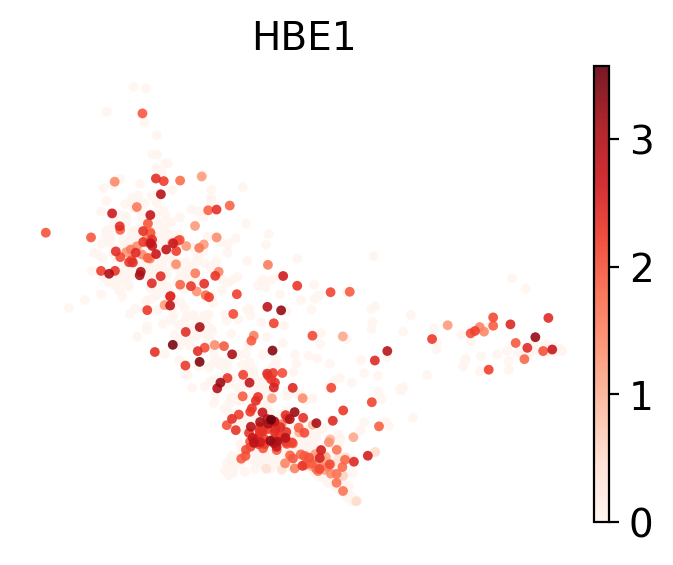

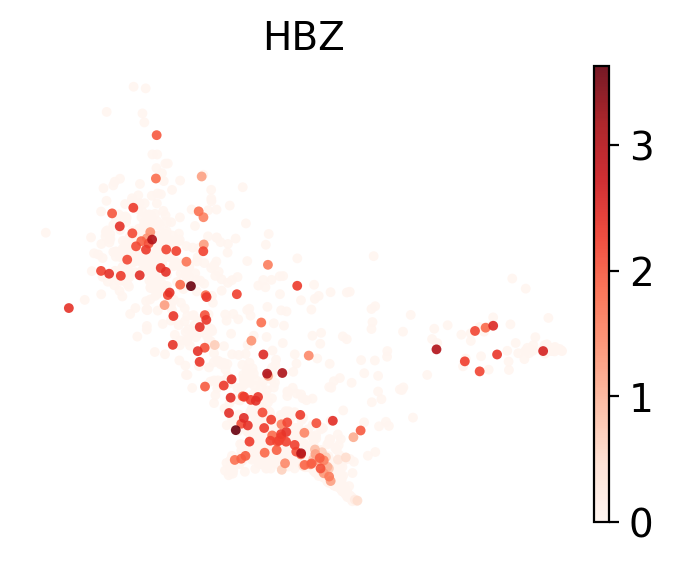

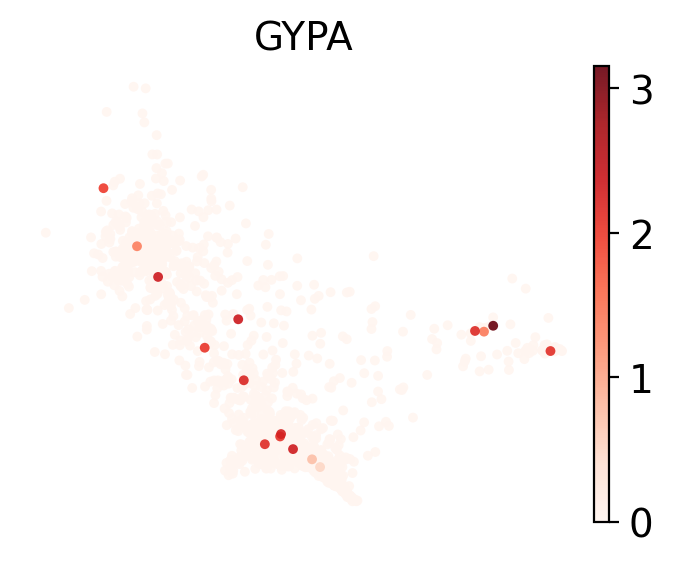

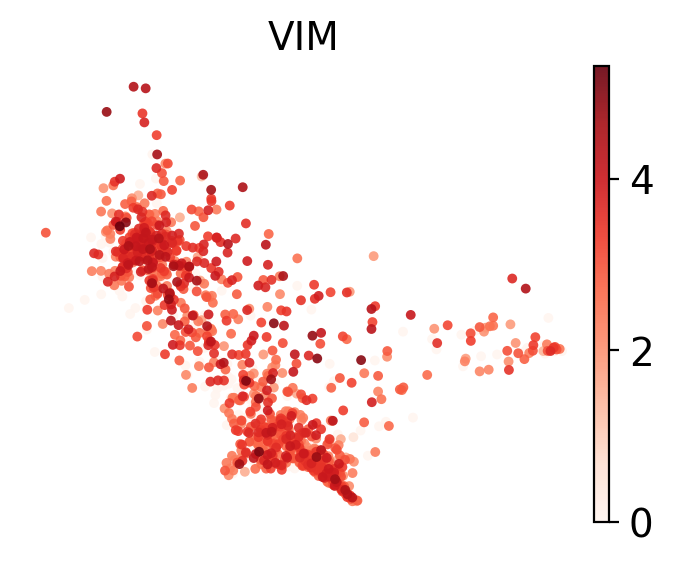

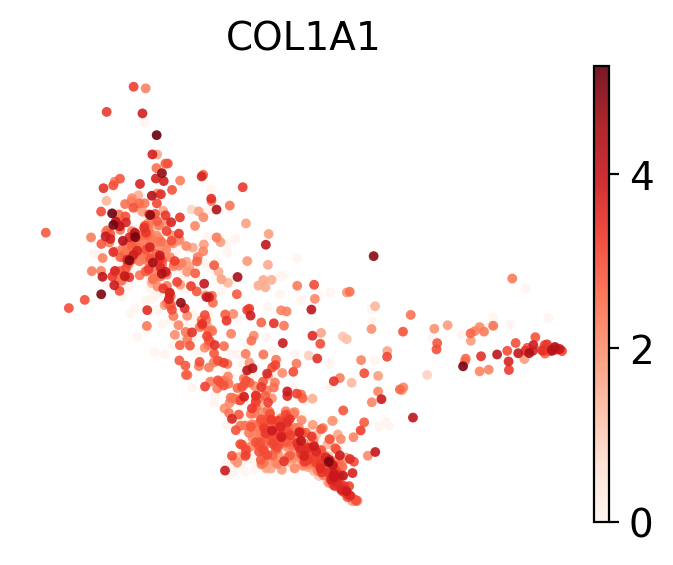

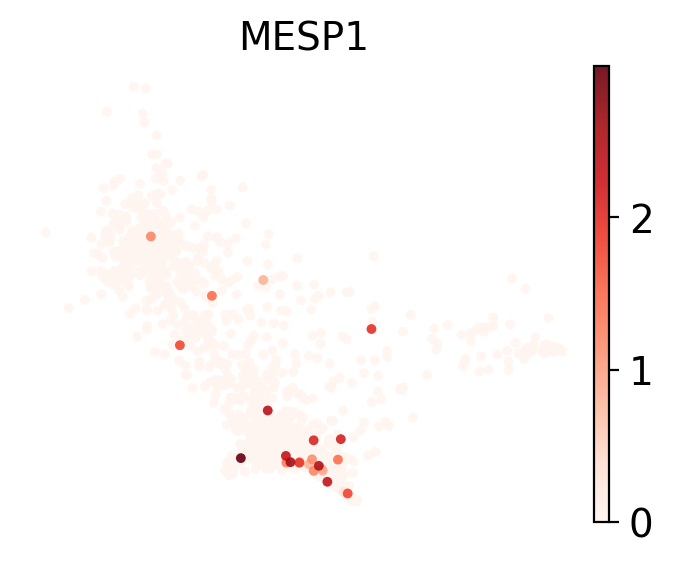

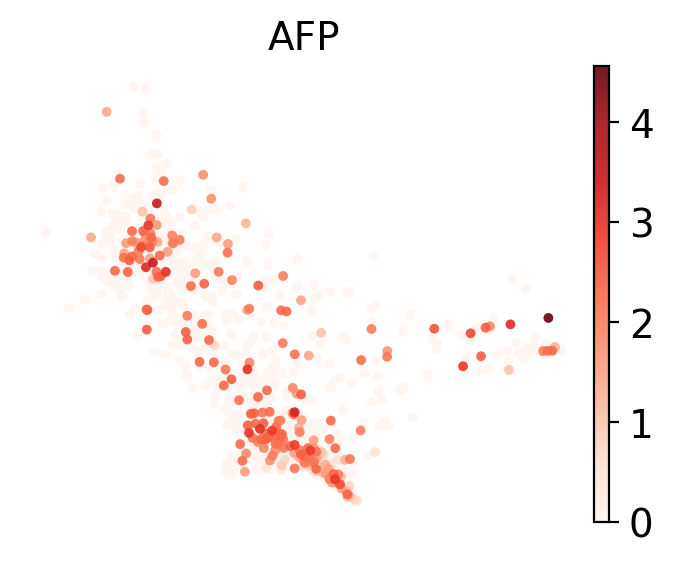

Skip TAL: not found in adata_q_model.var_names


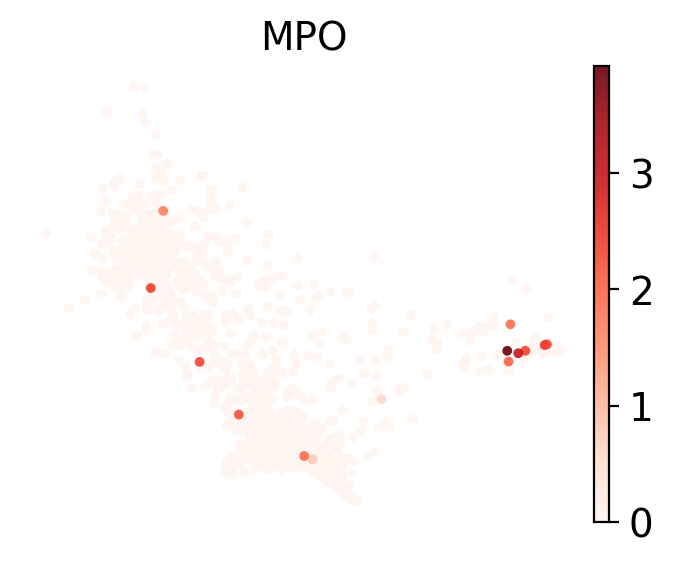

In [20]:
genes = ["CDX2", "KDR", "LMO2", "HBE1", "HBZ", "GYPA", "VIM", "COL1A1", "MESP1", "AFP", "TAL", "MPO"]

for gene in genes:
    if gene not in adata_q_model.var_names:
        print(f"Skip {gene}: not found in adata_q_model.var_names")
        continue

    fig, ax = plt.subplots(figsize=(4, 3))

    sc.pl.umap(
        adata_q_model,
        color=gene,
        cmap="Reds",
        frameon=False,
        size=50,
        alpha=0.9,
        title=gene,
        ax=ax,
        show=False,
    )

    fig.savefig(
        fig_dir / f"projection_HCEB_Trans_ExM_{gene}.pdf",
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close(fig)

## method 2 load data (no)

In [3]:
query_path = out_dir / "hemo_d1_10_revised_annotation.h5ad"
ref_path = "/mnt/yiming/nfs_share/projects/hypoblast/data/processed/cs6_sub.h5ad"
# adata_ref = adata_sub
adata_hemo = sc.read_h5ad(query_path)
adata_ref = sc.read_h5ad(ref_path)

adata_ref.var_names_make_unique()
adata_hemo.var_names_make_unique()

In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.neighbors import NearestNeighbors

ref_label_key = "celltype_final"
query_label_key = "CellType_short"

exm_groups = [
    "Nasc Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
]

adata_q = adata_hemo[
    adata_hemo.obs[query_label_key].astype(str).isin(exm_groups)
].copy()

common_genes = adata_ref.var_names.intersection(adata_q.var_names)

adata_ref_p = adata_ref[:, common_genes].copy()
adata_q_p = adata_q[:, common_genes].copy()

# HVG on reference only
sc.pp.highly_variable_genes(
    adata_ref_p,
    n_top_genes=3000,
    flavor="cell_ranger",
)

hvg = adata_ref_p.var["highly_variable"].values

adata_ref_p = adata_ref_p[:, hvg].copy()
adata_q_p = adata_q_p[:, adata_ref_p.var_names].copy()

# scale reference
sc.pp.scale(adata_ref_p, max_value=10)

ref_mean = adata_ref_p.var["mean"].values
ref_std = adata_ref_p.var["std"].values
ref_std[ref_std == 0] = 1

# PCA on reference only
sc.tl.pca(
    adata_ref_p,
    n_comps=50,
    svd_solver="arpack",
)

# scale query using reference mean/std
Xq = adata_q_p.X
if sparse.issparse(Xq):
    Xq = Xq.toarray()
else:
    Xq = np.asarray(Xq)

Xq_scaled = (Xq - ref_mean) / ref_std
Xq_scaled = np.clip(Xq_scaled, -10, 10)

adata_q_p.X = Xq_scaled

# project query into reference PCA space
PCs = adata_ref_p.varm["PCs"][:, :50]
adata_q_p.obsm["X_pca"] = adata_q_p.X @ PCs

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:40)


In [5]:
k = 30

nn = NearestNeighbors(
    n_neighbors=k,
    metric="euclidean",
)

nn.fit(adata_ref_p.obsm["X_pca"])

distances, indices = nn.kneighbors(adata_q_p.obsm["X_pca"])

In [6]:
emb_key = "X_umap"   
ref_umap = adata_ref.obsm[emb_key]

ref_neighbor_umap = ref_umap[indices]   # shape: query cells x k x 2

# inverse distance weights
eps = 1e-6
weights = 1 / (distances + eps)
weights = weights / weights.sum(axis=1, keepdims=True)

query_umap_weighted = np.sum(
    ref_neighbor_umap * weights[:, :, None],
    axis=1,
)

adata_q_p.obsm["X_umap_projected_to_existing_ref"] = query_umap_weighted

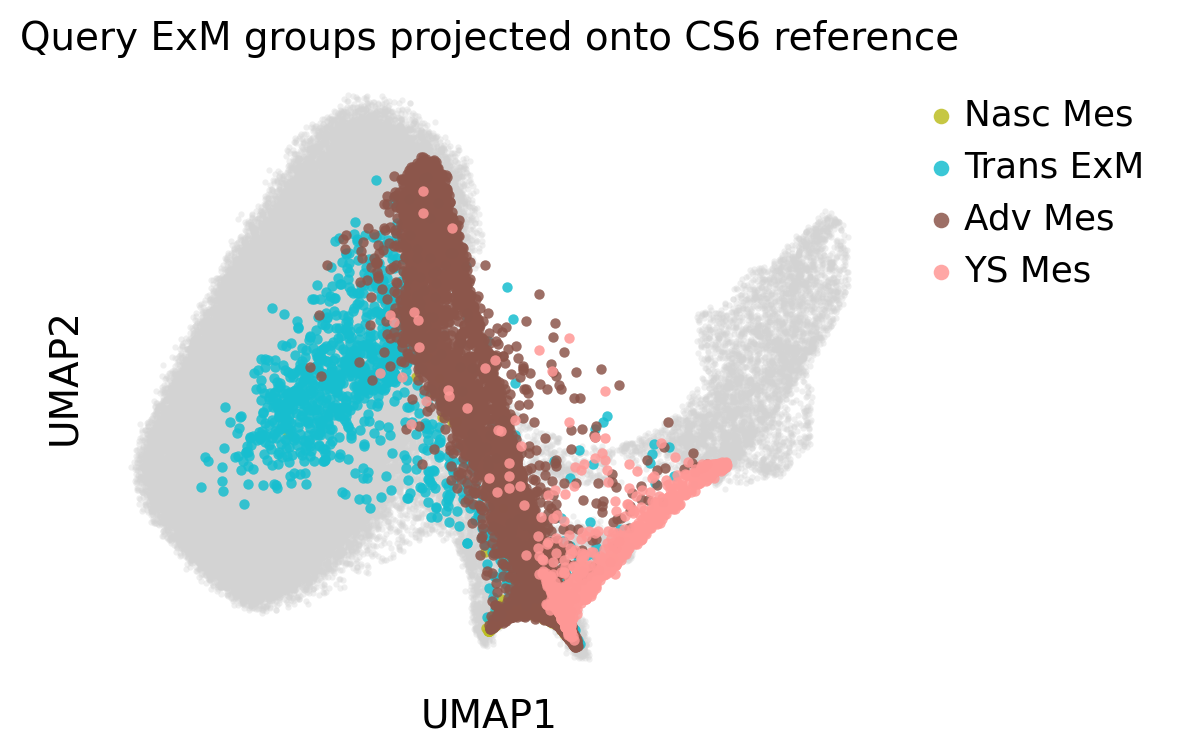

In [7]:
import matplotlib.pyplot as plt

query_color_map = {
    "Nasc Mes": "#BCBD22",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",
}

fig, ax = plt.subplots(figsize=(6, 4))

# Reference background
ax.scatter(
    adata_ref.obsm[emb_key][:, 0],
    adata_ref.obsm[emb_key][:, 1],
    s=5,
    c="lightgrey",
    alpha=0.35,
    linewidths=0,
)

# Query projection
for group in exm_groups:
    mask = adata_q_p.obs[query_label_key].astype(str) == group
    
    ax.scatter(
        adata_q_p.obsm["X_umap_projected_to_existing_ref"][mask, 0],
        adata_q_p.obsm["X_umap_projected_to_existing_ref"][mask, 1],
        s=14,
        c=query_color_map.get(group, "black"),
        alpha=0.85,
        linewidths=0,
        label=group,
    )

ax.set_title("Query ExM groups projected onto CS6 reference", fontsize=14)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# remove frame
ax.set_frame_on(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False,
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    markerscale=1.5,
)

plt.tight_layout()
plt.show()

In [8]:
ref_labels = adata_ref_p.obs[ref_label_key].astype(str).values
query_groups = adata_q_p.obs[query_label_key].astype(str).values

records = []

for i in range(adata_q_p.n_obs):
    q_group = query_groups[i]
    neigh_labels = ref_labels[indices[i]]
    
    vc = pd.Series(neigh_labels).value_counts()
    
    for ref_ct, n in vc.items():
        records.append({
            "query_cell": adata_q_p.obs_names[i],
            "query_group": q_group,
            "ref_celltype": ref_ct,
            "n_neighbors": n,
            "fraction_neighbors": n / k,
            "mean_distance": distances[i].mean(),
        })

cell_neighbor_df = pd.DataFrame(records)

group_neighbor_df = (
    cell_neighbor_df
    .groupby(["query_group", "ref_celltype"])["n_neighbors"]
    .sum()
    .reset_index()
)

group_neighbor_df["percentage"] = (
    group_neighbor_df["n_neighbors"]
    / group_neighbor_df.groupby("query_group")["n_neighbors"].transform("sum")
    * 100
)

group_neighbor_df = group_neighbor_df.sort_values(
    ["query_group", "percentage"],
    ascending=[True, False],
)

group_neighbor_df.head(30)

,query_group,ref_celltype,n_neighbors,percentage
0,Adv Mes,AM.EXMC,338643,77.151938
3,Adv Mes,PL.EXMC,94966,21.635796
2,Adv Mes,Hypo.2,3287,0.748867
4,Adv Mes,YS.EXMC,2027,0.461805
1,Adv Mes,Hypo.1,5,0.001139
5,Adv Mes,YS.Endo,2,0.000456
6,Nasc Mes,AM.EXMC,41254,97.943970
7,Nasc Mes,Hypo.2,561,1.331909
8,Nasc Mes,PL.EXMC,305,0.724122
13,Trans ExM,PL.EXMC,25609,67.856386


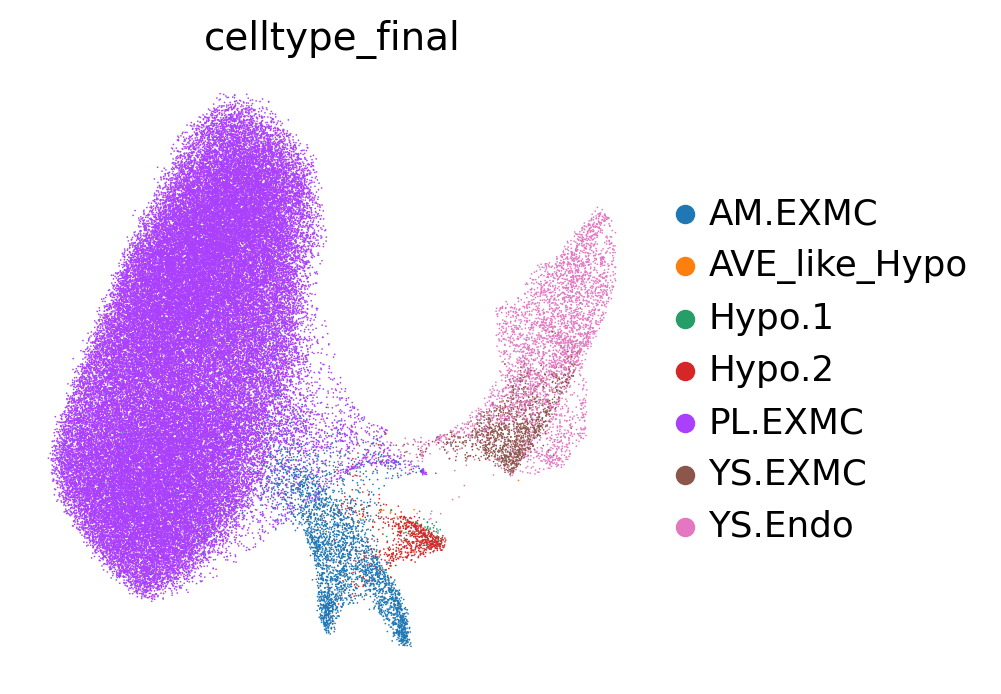

In [14]:
sc.pl.umap(
    adata_ref,
    color=["celltype_final"],
    frameon=False,
    wspace=0.4,
)